# 05 XAI, robustez y errores

Este notebook audita el modelo final. No cambia el modelo seleccionado, no ajusta hiperparámetros y no modifica umbrales.

La auditoría cubre tres aspectos. Primero se estudia qué variables influyen más mediante permutation importance. Después se analizan falsos positivos y falsos negativos en test. Finalmente se revisa la robustez ante ruido y posibles diferencias de distribución entre train y test.
Auditar el modelo es necesario porque el proyecto no termina al obtener buenas métricas. En mantenimiento predictivo, un modelo debe ser comprensible, debe mostrar qué variables influyen en sus decisiones y debe tener un comportamiento razonable ante ruido o cambios de distribución.

Este notebook no intenta mejorar el modelo. Su objetivo es explicar riesgos y limitaciones. Por eso los análisis se presentan como auditoría posterior y no como una nueva fase de selección.


## Preparación

Esta celda carga las librerías necesarias para interpretar el modelo, analizar errores y crear figuras. También prepara las carpetas de salida.

No se entrena un modelo nuevo. Todo el notebook parte del modelo ya guardado por el modelado supervisado.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_utils import *

RANDOM_STATE = 42
crear_carpetas(".")
sns.set_theme(style="whitegrid")


El entorno queda listo para cargar el modelo final y sus datos. Las salidas de este notebook son de auditoría y no forman parte de la selección del modelo.


## Carga del modelo final

Esta sección carga train, test y el modelo guardado en `artifacts/models`. Ese modelo procede del notebook 02 y fue seleccionado con CV sobre train.

Aquí no se reentrena el modelo. Esto es importante porque la auditoría debe explicar el modelo fijado, no crear otro modelo diferente.


In [2]:
from sklearn.inspection import permutation_importance
from scipy.stats import ks_2samp

train_df = cargar_csv("data/processed/train.csv")
test_df = cargar_csv("data/processed/test.csv")
X_train, y_train = separar_x_y(train_df)
X_test, y_test = separar_x_y(test_df)
model = cargar_modelo("artifacts/models/best_model.joblib")


El modelo queda cargado para su análisis. Test no se usa para cambiarlo. Solo se usará en el análisis de errores finales y en la comparación de distribuciones.


## Permutation importance

Esta sección calcula permutation importance sobre una muestra de train. La idea es medir cuánto baja average precision cuando se desordena una variable.

Usar train para este análisis evita convertir test en una herramienta de sensibilidad. La interpretación es útil para auditar el modelo, pero no demuestra causalidad. SHAP no forma parte de este notebook.
Permutation importance es una técnica sencilla y defendible para estimar importancia de variables. La idea es romper la relación entre una variable y la etiqueta, y medir cuánto empeora la métrica. Si el rendimiento cae mucho, esa variable era importante para el modelo.

El análisis se hace sobre una muestra de train para no usar test como herramienta de sensibilidad. SHAP no forma parte de este notebook, por lo que no se prometen explicaciones que no se calculan.


  File "c:\Users\mauro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


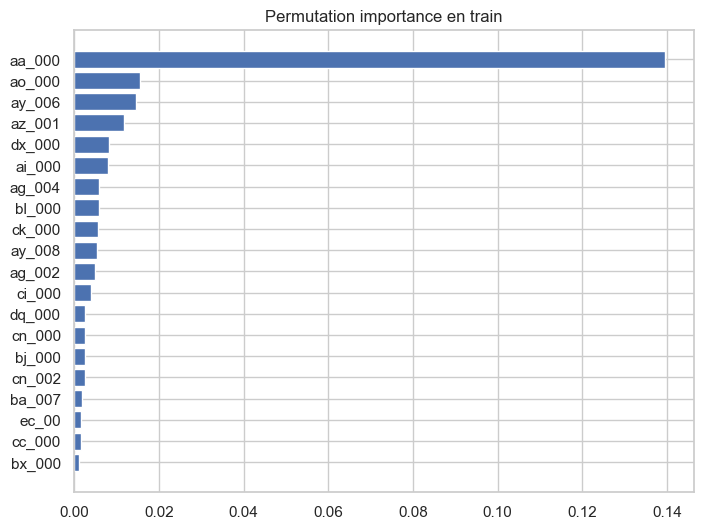

,feature,importance_mean,importance_std
0,aa_000,0.139433,2.518179e-02
23,ao_000,0.015585,1.291882e-03
38,ay_006,0.014519,8.036471e-03
43,az_001,0.011804,4.289924e-03
151,dx_000,0.008227,4.114017e-03
17,ai_000,0.007979,9.529623e-04
10,ag_004,0.005894,6.327003e-03
72,bl_000,0.005870,5.129974e-03
96,ck_000,0.005591,6.490798e-04
40,ay_008,0.005377,3.795280e-03


In [3]:
X_pi = X_train.sample(n=min(3000, len(X_train)), random_state=RANDOM_STATE)
y_pi = y_train.loc[X_pi.index]
perm = permutation_importance(model, X_pi, y_pi, n_repeats=5, random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1)
importance_df = pd.DataFrame({"feature": X_train.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=False)
importance_df.to_csv("artifacts/metrics/permutation_importance.csv", index=False)
top = importance_df.head(20).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["importance_mean"])
ax.set_title("Permutation importance en train")
guardar_figura(fig, "artifacts/figures/feature_importance.png")
plt.show()
importance_df.head(20)


La variable más importante es **aa_000**, con una diferencia clara respecto al resto. También aparecen variables como `ao_000`, `ay_006`, `az_001` y `dx_000`.

Esto indica que el modelo depende especialmente de ciertos sensores o agregados. La lectura debe ser prudente. Una variable importante para predecir no tiene por qué ser la causa directa del fallo APS.
Que `aa_000` aparezca como variable dominante indica que el modelo depende mucho de esa señal. Las variables siguientes también aportan información, pero con menor impacto relativo.

La interpretación debe ser técnica y no causal. Una variable puede ser útil para predecir APS porque está correlacionada con el fallo, porque resume actividad del sistema o porque captura un patrón indirecto. Para hablar de causalidad haría falta conocimiento experto del dominio.


## Análisis de errores

Esta sección usa test para estudiar los errores finales del modelo ya fijado. El uso de test aquí es una auditoría posterior, no una fase de selección.

Analizar falsos positivos y falsos negativos es importante porque el coste de los errores es asimétrico. Los falsos negativos representan fallos APS no detectados y son los casos más delicados.


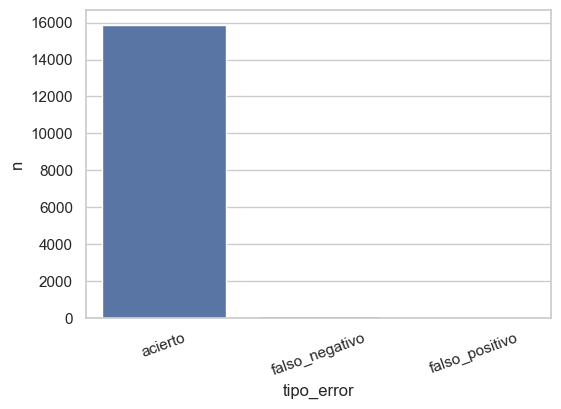

,tipo_error,n
0,acierto,15894
1,falso_negativo,93
2,falso_positivo,13


In [4]:
y_pred = model.predict(X_test)
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred
error_df["tipo_error"] = "acierto"
error_df.loc[(error_df.y_true == 1) & (error_df.y_pred == 0), "tipo_error"] = "falso_negativo"
error_df.loc[(error_df.y_true == 0) & (error_df.y_pred == 1), "tipo_error"] = "falso_positivo"
error_summary = error_df["tipo_error"].value_counts().rename_axis("tipo_error").reset_index(name="n")
error_summary.to_csv("artifacts/metrics/error_analysis.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=error_summary, x="tipo_error", y="n", ax=ax)
ax.tick_params(axis="x", rotation=20)
guardar_figura(fig, "artifacts/figures/error_summary.png")
plt.show()
error_summary


El modelo comete **93 falsos negativos** y **13 falsos positivos** en test. La diferencia muestra que el modelo es conservador con las falsas alarmas, pero todavía deja escapar algunos fallos APS.

Esta información ayuda a explicar las limitaciones del sistema. No se usa para cambiar el modelo ni para ajustar un umbral mirando test.
La separación entre falsos negativos y falsos positivos es clave para la discusión. Los 13 falsos positivos indican pocas revisiones innecesarias. Los 93 falsos negativos son más preocupantes porque representan fallos APS no detectados.

Esta lectura ayuda a explicar por qué el coste aparece en el proyecto. Aunque el modelo tenga buen rendimiento global, los errores que quedan no tienen todos la misma gravedad.


## Ejemplo local sencillo

Esta sección muestra un caso concreto de error usando las variables más importantes. Es una explicación local simple para entender qué valores aparecen en un fallo del modelo.

La lectura local ayuda a comunicar el comportamiento del clasificador, pero no sustituye un análisis causal ni una validación técnica con expertos del dominio.


In [5]:
top_features = importance_df.head(10)["feature"].tolist()
fn_cases = error_df[error_df["tipo_error"] == "falso_negativo"]
if len(fn_cases) > 0:
    local_example = fn_cases.iloc[[0]][top_features + ["y_true", "y_pred", "tipo_error"]]
else:
    local_example = error_df.iloc[[0]][top_features + ["y_true", "y_pred", "tipo_error"]]
local_example.to_csv("artifacts/metrics/local_error_example.csv", index=False)
local_example


,aa_000,ao_000,ay_006,az_001,dx_000,ai_000,ag_004,bl_000,ck_000,ay_008,y_true,y_pred,tipo_error
426,1055714,48131824.0,29340102.0,111650.0,0.0,24374.0,196186.0,268680.0,8332377.6,3813882.0,1,0,falso_negativo


El ejemplo permite revisar un falso negativo concreto. Este tipo de análisis es útil para detectar patrones de error que podrían discutirse con personal de mantenimiento.

Aun así, no se debe ajustar el modelo a partir de un caso aislado de test. El caso sirve para interpretación y no para selección.


## Robustez con ruido

Esta sección añade ruido a variables numéricas sobre una muestra de train. El objetivo es comprobar si pequeñas perturbaciones en las entradas reducen el rendimiento.

No se trata de un ataque adversarial avanzado. Es una prueba sencilla de sensibilidad. Se hace sobre train para que test no se convierta en una herramienta de ajuste.


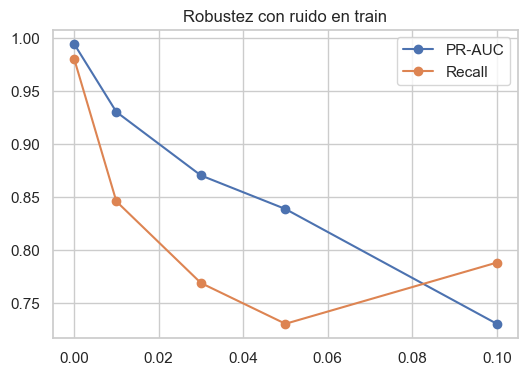

,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,tn,fp,fn,tp,coste,modelo,noise_level
0,0.999667,0.990385,1.000000,0.980769,0.990291,0.999870,0.994658,2948,0,1,51,500,noise_0,0.00
1,0.996000,0.922398,0.916667,0.846154,0.880000,0.995714,0.930465,2944,4,8,44,4040,noise_0.01,0.01
2,0.993667,0.883428,0.851064,0.769231,0.808081,0.978401,0.870601,2941,7,12,40,6070,noise_0.03,0.03
3,0.991333,0.863349,0.760000,0.730769,0.745098,0.972811,0.838957,2936,12,14,38,7120,noise_0.05,0.05
4,0.989333,0.890669,0.661290,0.788462,0.719298,0.986151,0.730761,2927,21,11,41,5710,noise_0.1,0.10


In [6]:
rng = np.random.default_rng(RANDOM_STATE)
num_cols = obtener_variables_numericas(X_train)
stds = X_train[num_cols].std().replace(0, 1)
X_robust = X_train.sample(n=min(3000, len(X_train)), random_state=RANDOM_STATE)
y_robust = y_train.loc[X_robust.index]
rows = []

for level in [0, 0.01, 0.03, 0.05, 0.1]:
    X_noisy = X_robust.copy()
    noise = rng.normal(0, 1, size=X_noisy[num_cols].shape)
    X_noisy[num_cols] = X_noisy[num_cols] + noise * stds.values * level
    row = evaluar_modelo(f"noise_{level}", model, X_noisy, y_robust)
    row["noise_level"] = level
    rows.append(row)

robustness_df = pd.DataFrame(rows)
robustness_df.to_csv("artifacts/metrics/robustness_results.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(robustness_df["noise_level"], robustness_df["pr_auc"], marker="o", label="PR-AUC")
ax.plot(robustness_df["noise_level"], robustness_df["recall_pos"], marker="o", label="Recall")
ax.set_title("Robustez con ruido en train")
ax.legend()
guardar_figura(fig, "artifacts/figures/robustness_curve.png")
plt.show()
robustness_df


Los resultados muestran que el rendimiento baja cuando aumenta el ruido. PR-AUC y F1 se reducen con perturbaciones pequeñas, lo que indica sensibilidad moderada a cambios en variables numéricas.

Esta lectura es relevante para despliegue. En sensores reales puede haber ruido de medida, calibraciones distintas o condiciones de registro variables. El modelo funciona bien, pero conviene vigilar la calidad de entrada.
La robustez con ruido muestra que el modelo pierde rendimiento cuando las variables se perturban. Esto no invalida el modelo, pero indica que la calidad de las mediciones sería importante en despliegue.

En sensores reales puede haber ruido, calibración distinta o condiciones ambientales que afecten a los valores. Por eso conviene presentar esta prueba como una comprobación de sensibilidad y no como una garantía completa de robustez.


## Shift entre train y test

Esta sección compara distribuciones de variables entre train y test mediante el estadístico KS. El objetivo es detectar diferencias fuertes entre particiones.

Este análisis no afirma deriva temporal porque el dataset no representa un flujo temporal de producción. Solo compara si las particiones disponibles parecen tener distribuciones muy distintas.


In [7]:
shift_cols = obtener_variables_numericas(X_train)
shift_rows = []
for col in shift_cols:
    a = X_train[col].dropna()
    b = X_test[col].dropna()
    if len(a) and len(b):
        stat, pvalue = ks_2samp(a, b)
        shift_rows.append({"feature": col, "ks_stat": stat, "pvalue": pvalue})
shift_df = pd.DataFrame(shift_rows).sort_values("ks_stat", ascending=False)
shift_df.to_csv("artifacts/metrics/shift_results.csv", index=False)
shift_df.head(20)


,feature,ks_stat,pvalue
78,br_000,0.022702,0.190590
77,bq_000,0.020786,0.251521
1,ab_000,0.015203,0.515160
76,bp_000,0.014494,0.643237
128,cz_000,0.012359,0.102362
87,cb_000,0.011972,0.055539
40,ay_008,0.011840,0.059944
70,bj_000,0.011837,0.059654
123,ct_000,0.011789,0.133745
3,ad_000,0.011769,0.143031


Los estadísticos KS principales son bajos en la tabla generada. No aparecen señales fuertes de cambio entre train y test para esas variables.

Esto apoya que la evaluación final es razonable, aunque no demuestra que el modelo vaya a mantenerse estable en producción. Para afirmar deriva real haría falta información temporal y monitorización continua.
El análisis de shift no muestra diferencias fuertes en las variables revisadas. Esto ayuda a confiar en que train y test no están radicalmente separados en esas señales.

Aun así, no debe confundirse con un estudio de deriva temporal. Para hablar de deriva harían falta datos ordenados en el tiempo y una monitorización posterior al despliegue. Aquí solo se compara la distribución de dos particiones del dataset.


## Cierre de auditoría

La auditoría completa la evaluación del modelo final. XAI ayuda a identificar variables relevantes, el análisis de errores muestra dónde falla el modelo, la robustez mide sensibilidad ante ruido y el shift revisa diferencias entre particiones.

Ninguna de estas partes cambia el modelo principal. Son análisis posteriores que ayudan a defender el proyecto y a explicar sus limitaciones reales antes de pensar en un despliegue.
La memoria debe presentar esta auditoría como una capa de interpretación y control. XAI permite explicar dependencias del modelo. El análisis de errores muestra riesgos concretos. Robustez y shift muestran qué habría que vigilar antes de usar el sistema en producción.

La limitación principal es que estas pruebas no convierten el modelo en infalible. Ayudan a entenderlo mejor y a comunicar sus riesgos de forma responsable.
